# 03 Datenvisualisierung und Exploration


## 1. Setup und Datenimport

Für die Visualisierung werden ausschließlich die im Cleaning exportierten Datensätze aus `cleaned_data/` verwendet.

In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [309]:
tb_analysis = pd.read_csv("cleaned_data/tb_analysis_cleaned.csv")
tb_cases = pd.read_csv("cleaned_data/tb_cases_analysis_cleaned.csv")
tb_dr = pd.read_csv("cleaned_data/tb_dr_analysis_cleaned.csv")
tb_outcome = pd.read_csv("cleaned_data/tb_outcome_analysis_cleaned.csv")

data_shapes = pd.DataFrame({
    "Datensatz": [
        "tb_analysis",
        "tb_cases",
        "tb_dr",
        "tb_outcome",
    ],
    "Zeilen": [
        len(tb_analysis),
        len(tb_cases),
        len(tb_dr),
        len(tb_outcome),
    ],
    "Spalten": [
        tb_analysis.shape[1],
        tb_cases.shape[1],
        tb_dr.shape[1],
        tb_outcome.shape[1],
    ],
})

data_shapes

,Datensatz,Zeilen,Spalten
0,tb_analysis,752,60
1,tb_cases,540,16
2,tb_dr,423,12
3,tb_outcome,413,15


## 2. Zwischenstand vor der Visualisierung

Bei der Analyse werden unter anderem mögliche Einflüsse durch folgende Variablen überprüft: 

- Randwerte der Ausgangsraten
- Kleine Ausgangsfallzahlen unter 10 pro Land und Jahr 
- Positives Therapie-Outcome von 100% in Zusammenhang mit der Kohortengröße 

Eine direkte Korrektur erfolgte bei den Resistenzraten: 
- Resistenzraten von `1.0` wurden bereits im Cleaning auf `NaN` gesetzt und sind im DR-Analysedatensatz nicht mehr enthalten.

Der nächste Schritt ist eine deskriptive Übersicht der drei Analyse-Datensätze, bevor Zusammenhänge visualisiert werden.

In [311]:
overview = pd.DataFrame({
    "Datensatz": ["Fallzahlen", "Resistenz", "Therapie-Outcome"],
    "Zeilen": [len(tb_cases), len(tb_dr), len(tb_outcome)],
    "Spalten": [tb_cases.shape[1], tb_dr.shape[1], tb_outcome.shape[1]],
    "Länder": [
        tb_cases["iso3"].nunique(),
        tb_dr["iso3"].nunique(),
        tb_outcome["iso3"].nunique(),
    ],
    "Jahre": [
        f"{tb_cases['year'].min()}-{tb_cases['year'].max()}",
        f"{tb_dr['year'].min()}-{tb_dr['year'].max()}",
        f"{tb_outcome['year'].min()}-{tb_outcome['year'].max()}",
    ],
})

overview


,Datensatz,Zeilen,Spalten,Länder,Jahre
0,Fallzahlen,540,16,145,2019-2023
1,Resistenz,423,12,121,2019-2023
2,Therapie-Outcome,413,15,133,2019-2022


## 3. Deskriptive Übersicht der Zielvariablen

In [312]:
target_variables = {
    "Fallzahl-Veränderung": (tb_cases, "c_newinc_percent_change_next_year"),
    "Rifampicin-Resistenz": (tb_dr, "rr_rate_new_next_year"),
    "MDR-TB": (tb_dr, "mdr_rate_new_next_year"),
    "Therapieerfolg": (tb_outcome, "treatment_success_rate_next_year"),
    "Letalitätsrate": (tb_outcome, "treatment_death_rate_next_year"),
    "Nicht erfolgreicher Verlauf": (tb_outcome, "unsuccessful_rate_next_year"),
}

descriptive = []
for name, (data, column) in target_variables.items():
    values = data[column]
    descriptive.append({
        "Zielvariable (im Folgejahr)": name,
        "Anzahl": values.count(),
        "Fehlend": values.isna().sum(),
        "Median": values.median(),
        "Minimum": values.min(),
        "Maximum": values.max(),
    })

display(pd.DataFrame(descriptive).round(3))

analysis_datasets = {
    "Fallzahlen": tb_cases,
    "Resistenz": tb_dr,
    "Therapie-Outcome": tb_outcome,
}
exposure_variables = {
    "Kontakt-Screening": "contact_screening_rate",
    "TPT-Beginn": "tpt_start_rate",
    "TPT-Abschluss": "tpt_completion_rate",
}

missingness = []
for dataset_name, data in analysis_datasets.items():
    for variable_name, column in exposure_variables.items():
        missingness.append({
            "Datensatz": dataset_name,
            "Ausgangsvariable": variable_name,
            "Verfügbar (n)": data[column].notna().sum(),
            "Fehlend (n)": data[column].isna().sum(),
            "Fehlend (%)": data[column].isna().mean() * 100,
        })

missingness = pd.DataFrame(missingness)
display(missingness.round({"Fehlend (%)": 1}))

,Zielvariable (im Folgejahr),Anzahl,Fehlend,Median,Minimum,Maximum
0,Fallzahl-Veränderung,540,0,1.099,-83.333,339.583
1,Rifampicin-Resistenz,423,0,0.019,0.000,0.415
2,MDR-TB,423,0,0.017,0.000,0.995
3,Therapieerfolg,413,0,0.844,0.000,1.000
4,Letalitätsrate,412,1,0.063,0.000,0.500
5,Nicht erfolgreicher Verlauf,410,3,0.121,0.000,1.000


,Datensatz,Ausgangsvariable,Verfügbar (n),Fehlend (n),Fehlend (%)
0,Fallzahlen,Kontakt-Screening,540,0,0.0
1,Fallzahlen,TPT-Beginn,499,41,7.6
2,Fallzahlen,TPT-Abschluss,341,199,36.9
3,Resistenz,Kontakt-Screening,423,0,0.0
4,Resistenz,TPT-Beginn,396,27,6.4
5,Resistenz,TPT-Abschluss,277,146,34.5
6,Therapie-Outcome,Kontakt-Screening,413,0,0.0
7,Therapie-Outcome,TPT-Beginn,382,31,7.5
8,Therapie-Outcome,TPT-Abschluss,254,159,38.5


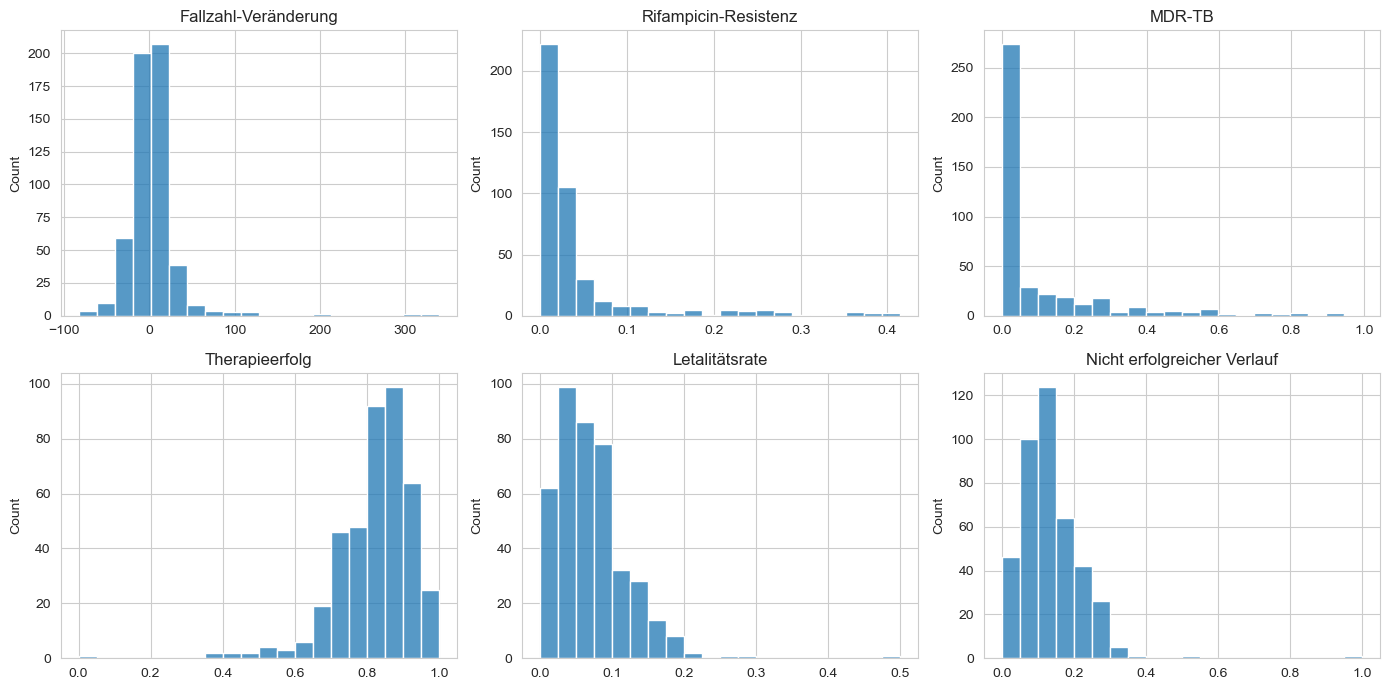

In [300]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, (name, (data, column)) in zip(axes.flat, target_variables.items()):
    sns.histplot(data=data, x=column, bins=20, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("")

plt.tight_layout()

## 4. Ausgangsraten und Veränderung der Fallzahlen

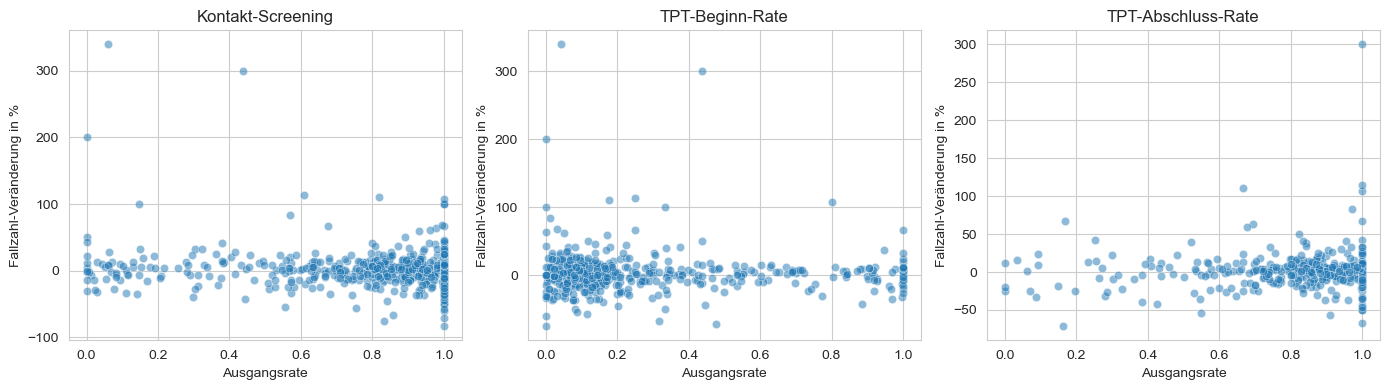

In [301]:
case_exposures = {
    "Kontakt-Screening": "contact_screening_rate",
    "TPT-Beginn-Rate": "tpt_start_rate",
    "TPT-Abschluss-Rate": "tpt_completion_rate",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, column) in zip(axes, case_exposures.items()):
    sns.scatterplot(
        data=tb_cases,
        x=column,
        y="c_newinc_percent_change_next_year",
        alpha=0.5,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Ausgangsrate")
    ax.set_ylabel("Fallzahl-Veränderung in %")

plt.tight_layout()

In [302]:
correlations = []
target = "c_newinc_percent_change_next_year"

for name, exposure in case_exposures.items():
    edge_flag = f"{exposure}_edge_flag"
    variants = {
        "Alle Werte": tb_cases,
        "Ohne Randwerte": tb_cases[~tb_cases[edge_flag]],
        "Ohne kleine Fallzahlen": tb_cases[~tb_cases["low_c_newinc_flag"]],
        "Ohne beides": tb_cases[~tb_cases[edge_flag] & ~tb_cases["low_c_newinc_flag"]],
    }

    for variant, data in variants.items():
        values = data[[exposure, target]].dropna()
        rho = values.corr(method="spearman").iloc[0, 1]
        correlations.append({
            "Ausgangsrate": name,
            "Analyse": variant,
            "n": len(values),
            "Spearman rho": rho,
        })

correlations = pd.DataFrame(correlations)

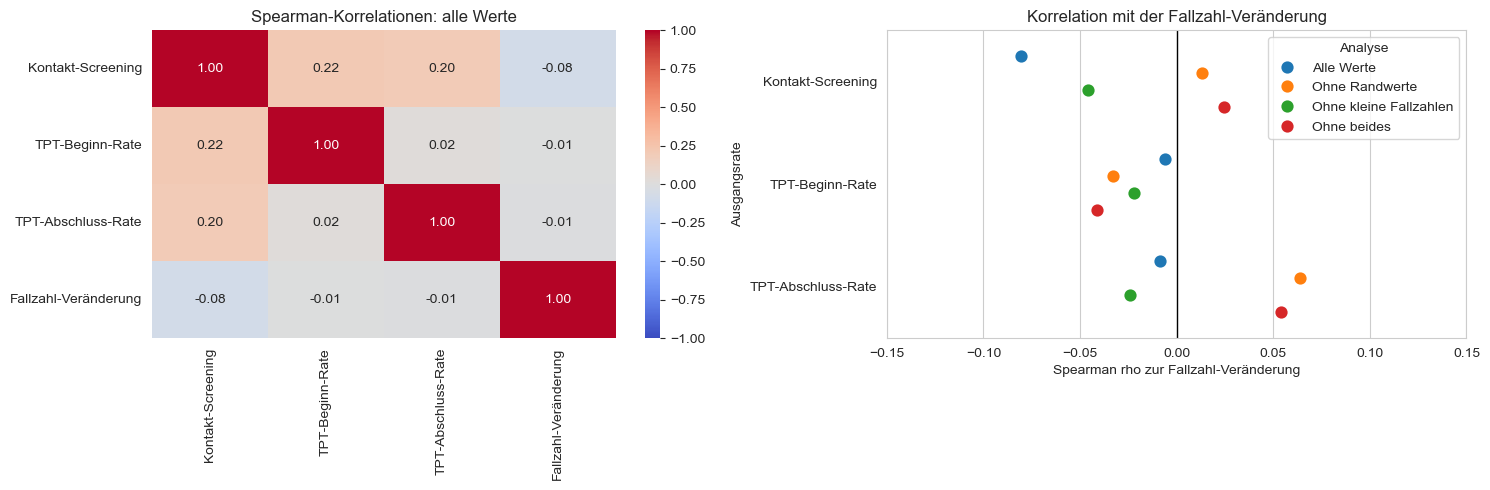

In [303]:
heatmap_columns = list(case_exposures.values()) + [target]
heatmap_labels = list(case_exposures.keys()) + ["Fallzahl-Veränderung"]
correlation_matrix = tb_cases[heatmap_columns].corr(method="spearman")
correlation_matrix.columns = heatmap_labels
correlation_matrix.index = heatmap_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title("Spearman-Korrelationen: alle Werte")

sns.pointplot(
    data=correlations,
    x="Spearman rho",
    y="Ausgangsrate",
    hue="Analyse",
    dodge=0.5,
    linestyles="none",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(-0.15, 0.15)
axes[1].set_title("Korrelation mit der Fallzahl-Veränderung")
axes[1].set_xlabel("Spearman rho zur Fallzahl-Veränderung")
plt.tight_layout()

***Bewertung:*** Zwischen den drei Ausgangsraten und der Veränderung der gemeldeten TB-Fälle im Folgejahr zeigt sich kein klares Muster. Auch ohne markierte Randwerte und kleine Ausgangsfallzahlen verändert sich das Gesamtbild nicht wesentlich.

## 5. Ausgangsraten und Resistenzraten im Folgejahr

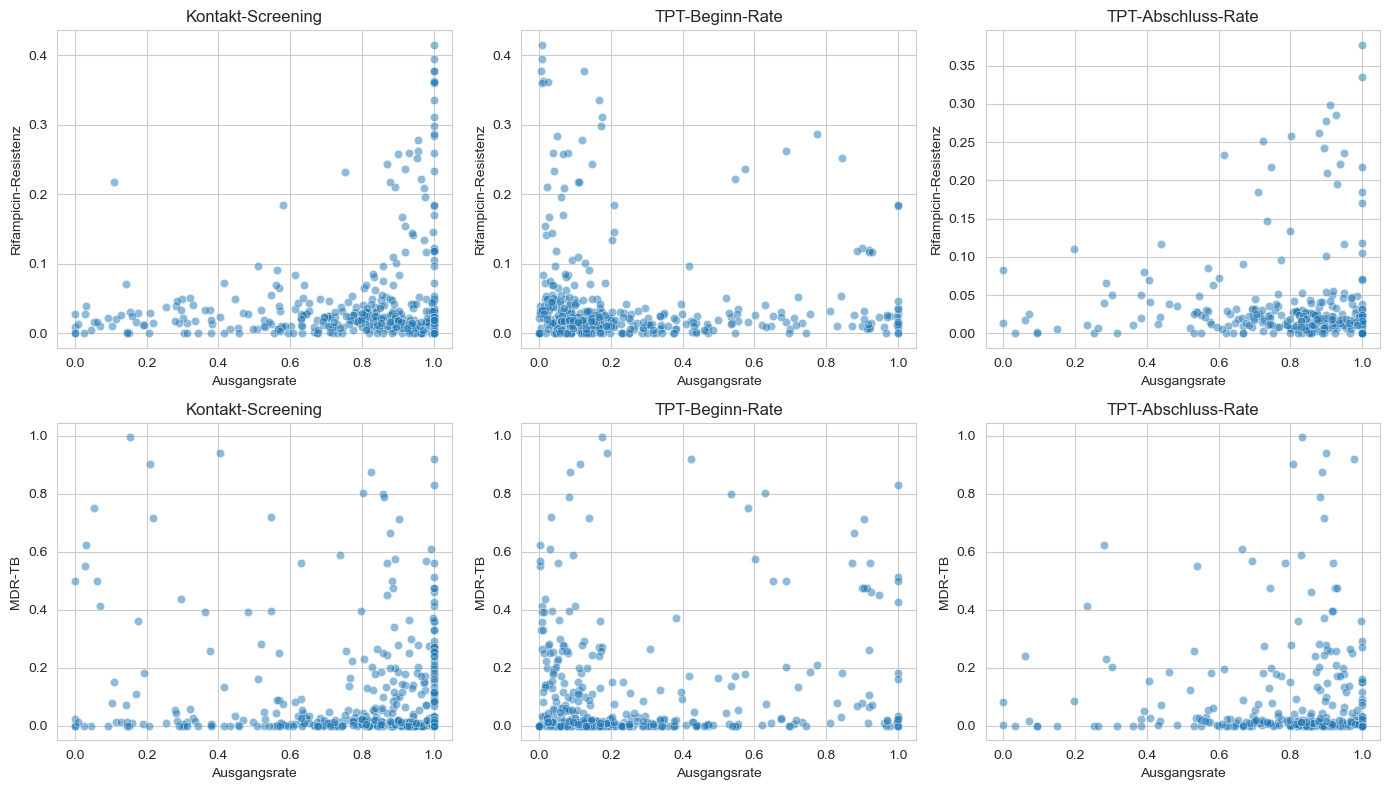

In [304]:
dr_targets = {
    "Rifampicin-Resistenz": "rr_rate_new_next_year",
    "MDR-TB": "mdr_rate_new_next_year",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row, (target_name, target_column) in enumerate(dr_targets.items()):
    for col, (exposure_name, exposure_column) in enumerate(case_exposures.items()):
        sns.scatterplot(
            data=tb_dr,
            x=exposure_column,
            y=target_column,
            alpha=0.5,
            ax=axes[row, col],
        )
        axes[row, col].set_title(exposure_name)
        axes[row, col].set_xlabel("Ausgangsrate")
        axes[row, col].set_ylabel(target_name)

plt.tight_layout()

In [305]:
dr_correlations = []

for target_name, target_column in dr_targets.items():
    for exposure_name, exposure_column in case_exposures.items():
        edge_flag = f"{exposure_column}_edge_flag"
        variants = {
            "Alle Werte": tb_dr,
            "Ohne Randwerte": tb_dr[~tb_dr[edge_flag]],
        }

        for variant, data in variants.items():
            values = data[[exposure_column, target_column]].dropna()
            rho = values.corr(method="spearman").iloc[0, 1]
            dr_correlations.append({
                "Vergleich": f"{exposure_name} / {target_name}",
                "Analyse": variant,
                "n": len(values),
                "Spearman rho": rho,
            })

dr_correlations = pd.DataFrame(dr_correlations)

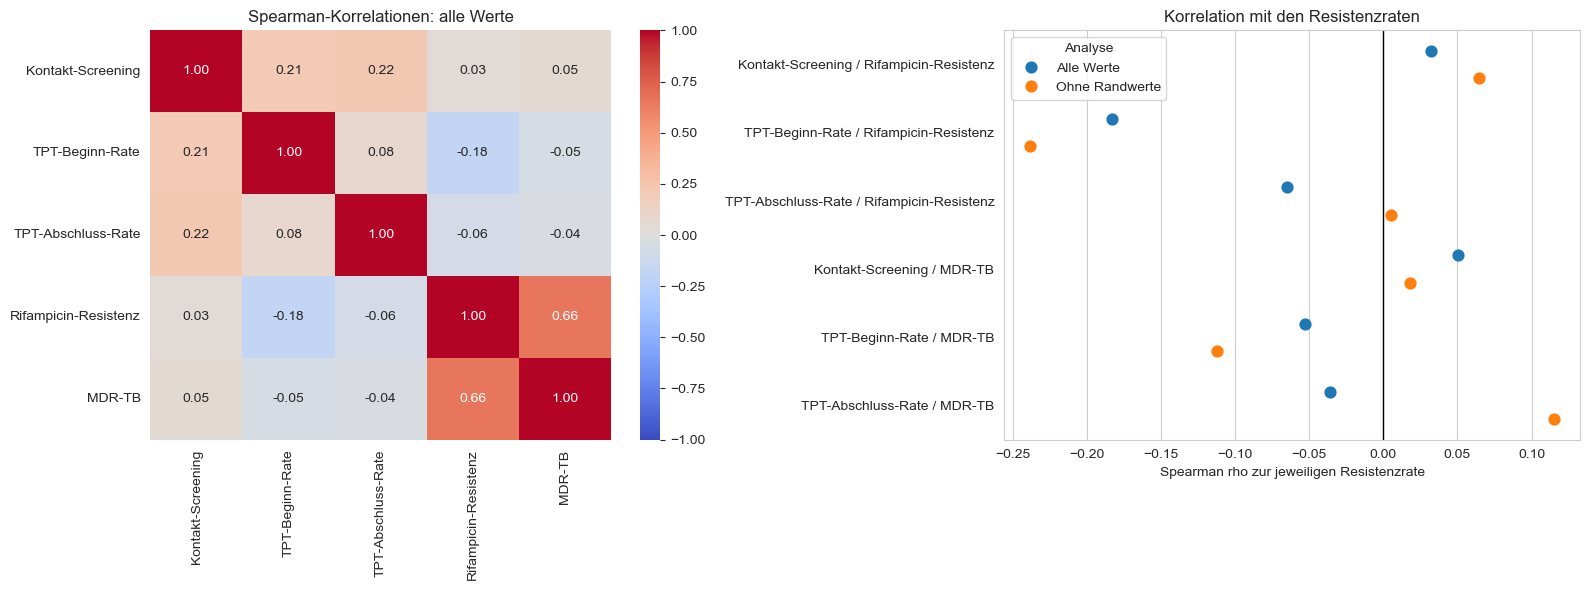

In [286]:
dr_columns = list(case_exposures.values()) + list(dr_targets.values())
dr_labels = list(case_exposures.keys()) + list(dr_targets.keys())
dr_matrix = tb_dr[dr_columns].corr(method="spearman")
dr_matrix.columns = dr_labels
dr_matrix.index = dr_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    dr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=axes[0],
)
axes[0].set_title("Spearman-Korrelationen: alle Werte")

sns.pointplot(
    data=dr_correlations,
    x="Spearman rho",
    y="Vergleich",
    hue="Analyse",
    dodge=0.4,
    linestyles="none",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Korrelation mit den Resistenzraten")
axes[1].set_xlabel("Spearman rho zur jeweiligen Resistenzrate")
axes[1].set_ylabel("")

plt.tight_layout()

***Bewertung:*** Bei den Resistenzraten ergibt sich kein einheitlicher Zusammenhang mit den untersuchten Screening- und TPT-Indikatoren. Der Ausschluss markierter Randwerte führt ebenfalls zu keiner grundlegenden Veränderung der Ergebnisse. Der Zusammenhang zwischen Rifampicin und Multi-Drug-Resistenz ist fachlich logisch und erwartbar, da eine MDR-TB definitionsgemäß gegen Isoniazid und Rifampicin resistent ist.

## 6. Ausgangsraten und Therapieergebnisse im Folgejahr

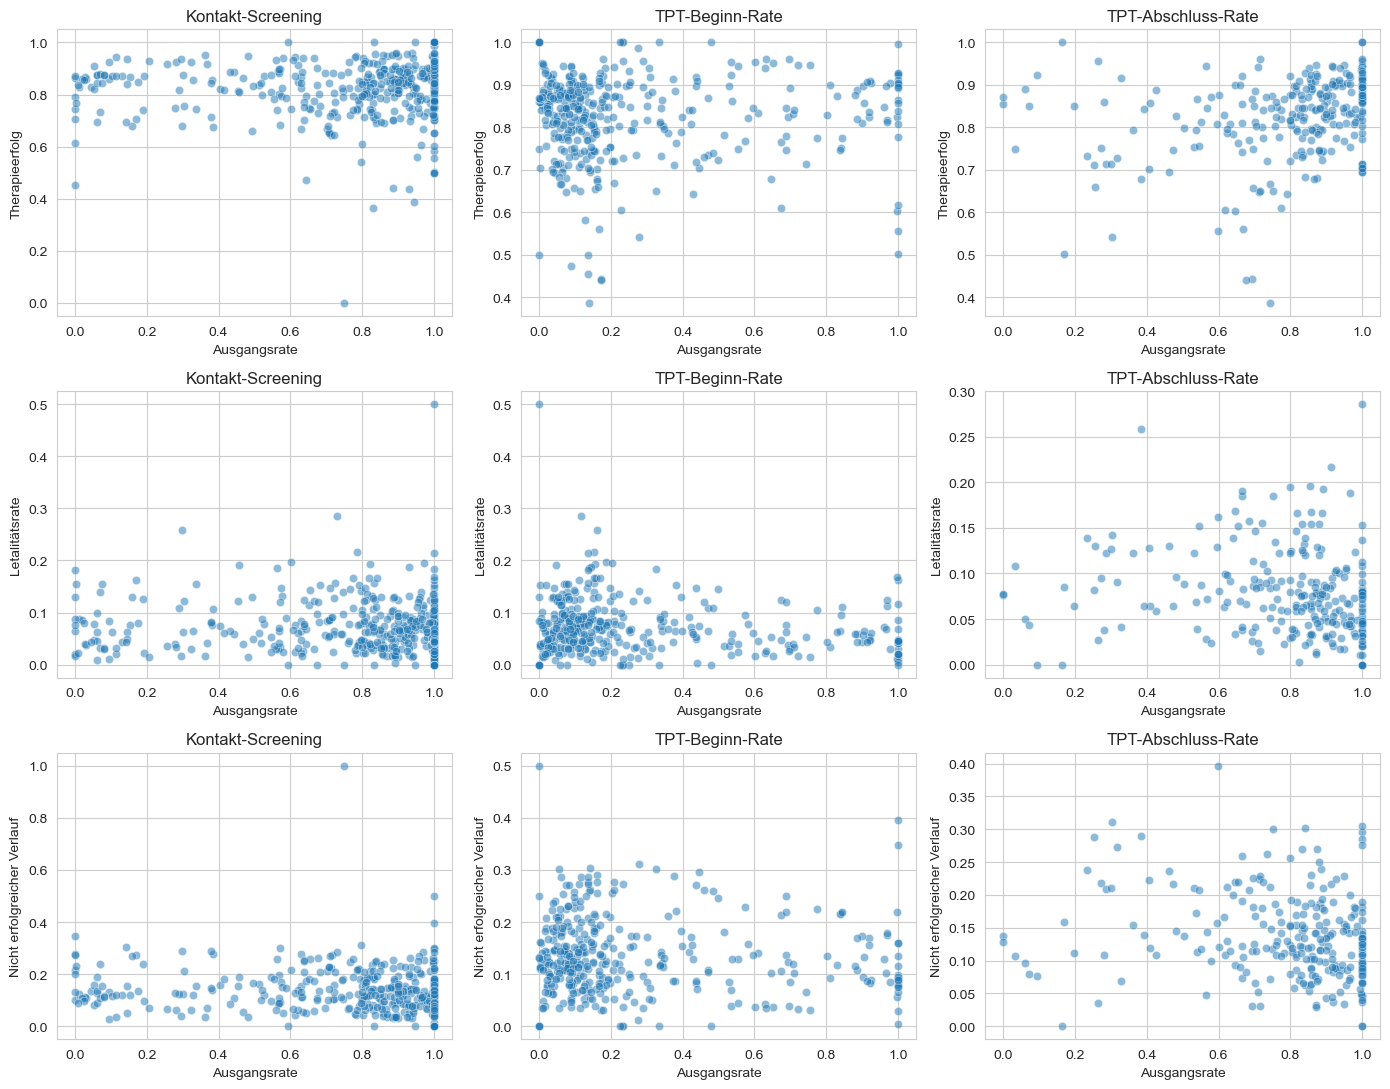

In [287]:
outcome_targets = {
    "Therapieerfolg": "treatment_success_rate_next_year",
    "Letalitätsrate": "treatment_death_rate_next_year",
    "Nicht erfolgreicher Verlauf": "unsuccessful_rate_next_year",
}

fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for row, (target_name, target_column) in enumerate(outcome_targets.items()):
    for col, (exposure_name, exposure_column) in enumerate(case_exposures.items()):
        sns.scatterplot(
            data=tb_outcome,
            x=exposure_column,
            y=target_column,
            alpha=0.5,
            ax=axes[row, col],
        )
        axes[row, col].set_title(exposure_name)
        axes[row, col].set_xlabel("Ausgangsrate")
        axes[row, col].set_ylabel(target_name)

plt.tight_layout()

In [288]:
outcome_correlations = []

for target_name, target_column in outcome_targets.items():
    for exposure_name, exposure_column in case_exposures.items():
        edge_flag = f"{exposure_column}_edge_flag"
        variants = {
            "Alle Werte": tb_outcome,
            "Ohne Randwerte": tb_outcome[~tb_outcome[edge_flag]],
        }

        for variant, data in variants.items():
            values = data[[exposure_column, target_column]].dropna()
            rho = values.corr(method="spearman").iloc[0, 1]
            outcome_correlations.append({
                "Vergleich": f"{exposure_name} / {target_name}",
                "Analyse": variant,
                "n": len(values),
                "Spearman rho": rho,
            })

outcome_correlations = pd.DataFrame(outcome_correlations)

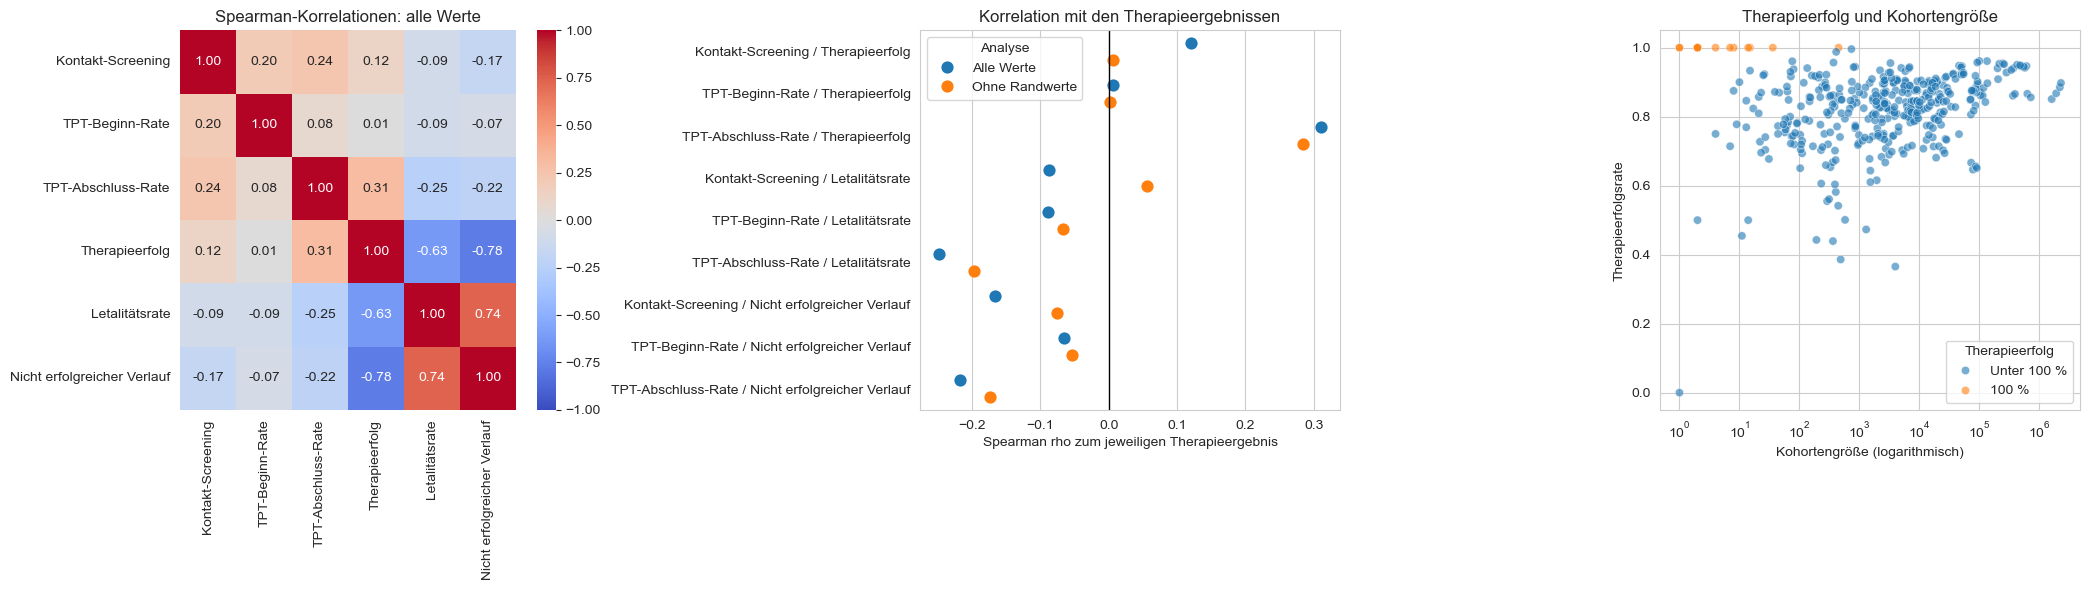

In [307]:
outcome_columns = list(case_exposures.values()) + list(outcome_targets.values())
outcome_labels = list(case_exposures.keys()) + list(outcome_targets.keys())
outcome_matrix = tb_outcome[outcome_columns].corr(method="spearman")
outcome_matrix.columns = outcome_labels
outcome_matrix.index = outcome_labels

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.heatmap(
    outcome_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=axes[0],
)
axes[0].set_title("Spearman-Korrelationen: alle Werte")

sns.pointplot(
    data=outcome_correlations,
    x="Spearman rho",
    y="Vergleich",
    hue="Analyse",
    dodge=0.4,
    linestyles="none",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Korrelation mit den Therapieergebnissen")
axes[1].set_xlabel("Spearman rho zum jeweiligen Therapieergebnis")
axes[1].set_ylabel("")

cohort_plot = tb_outcome[[
    "newrel_coh_next_year",
    "treatment_success_rate_next_year",
]].dropna()
cohort_plot = cohort_plot[cohort_plot["newrel_coh_next_year"] > 0].copy()
cohort_plot["Therapieerfolg"] = np.where(
    cohort_plot["treatment_success_rate_next_year"].eq(1),
    "100 %",
    "Unter 100 %",
)
sns.scatterplot(
    data=cohort_plot,
    x="newrel_coh_next_year",
    y="treatment_success_rate_next_year",
    hue="Therapieerfolg",
    alpha=0.6,
    ax=axes[2],
)
axes[2].set_xscale("log")
axes[2].set_title("Therapieerfolg und Kohortengröße")
axes[2].set_xlabel("Kohortengröße (logarithmisch)")
axes[2].set_ylabel("Therapieerfolgsrate")

plt.tight_layout()

 ***Anmerkung zu den Korrelationen der Therapieergebnisse:*** Da dieselben Behandlungsergebnisse teilweise in die Berechnung mehrerer Raten
  eingehen, sind die Korrelationen zwischen Letalität, Therapieerfolg und nicht erfolgreichen Verläufen teilweise mathematisch bedingt. Sie
  sind daher nicht als eigenständige medizinische Zusammenhänge zu interpretieren.

***Bewertung:*** Bei den Therapieergebnissen treten einzelne schwache bis moderate Korrelationen auf, jedoch kein konsistentes Muster über alle Ausgangsraten und Zielvariablen hinweg. Therapieerfolge von 100 % finden sich überwiegend bei kleinen Kohorten, vereinzelt aber auch bei größeren Kohorten (unter 1000) und sind damit nicht prinzipiell als unplausibel zu werten.

## 7. Explorative Analyse nach WHO-Region

Die regionale Abdeckung ist ungleich. In der Fallzahlanalyse sind beispielsweise 9 Länder aus SEA und 24 Länder aus EUR vertreten. SEA weist damit relativ zur bereinigten Ausgangsbasis eine hohe Abdeckung auf, die regionalen Kennzahlen beruhen jedoch auf wenigen Ländern. Die folgenden Darstellungen dienen daher der explorativen Prüfung auf deutlich erkennbare regionsspezifische Muster und sind nicht als global repräsentative Schätzungen zu verstehen.

In [306]:
regional_country_counts = pd.DataFrame({
    "Bereinigte Ausgangsbasis": tb_analysis.groupby("g_whoregion")["iso3"].nunique(),
    "Fallzahlen": tb_cases.groupby("g_whoregion")["iso3"].nunique(),
    "Resistenz": tb_dr.groupby("g_whoregion")["iso3"].nunique(),
    "Therapie-Outcome": tb_outcome.groupby("g_whoregion")["iso3"].nunique(),
})
regional_country_counts.index.name = "WHO-Region"

regional_coverage = regional_country_counts.iloc[:, 1:].div(
    regional_country_counts["Bereinigte Ausgangsbasis"], axis=0
).mul(100)

display(regional_country_counts)
display(regional_coverage.round(1).rename(columns=lambda column: f"{column} (%)"))

,Bereinigte Ausgangsbasis,Fallzahlen,Resistenz,Therapie-Outcome
WHO-Region,,,,
AFR,40,37,32,33
AMR,38,32,25,28
EMR,21,18,18,18
EUR,28,24,22,22
SEA,10,9,6,8
WPR,32,25,18,24


,Fallzahlen (%),Resistenz (%),Therapie-Outcome (%)
WHO-Region,,,
AFR,92.5,80.0,82.5
AMR,84.2,65.8,73.7
EMR,85.7,85.7,85.7
EUR,85.7,78.6,78.6
SEA,90.0,60.0,80.0
WPR,78.1,56.2,75.0


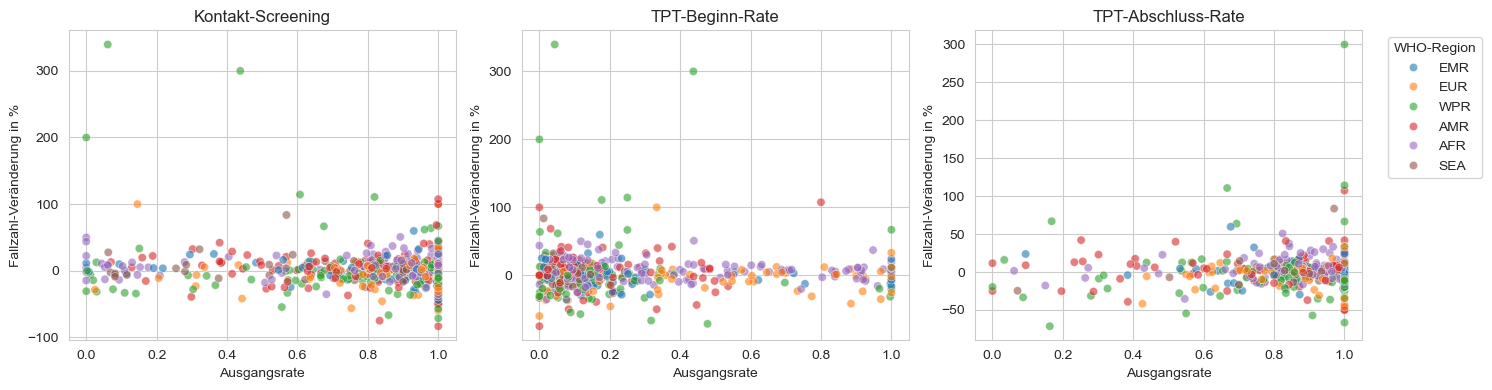

In [291]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, (name, exposure) in enumerate(case_exposures.items()):
    sns.scatterplot(
        data=tb_cases,
        x=exposure,
        y=target,
        hue="g_whoregion",
        alpha=0.6,
        ax=axes[col],
        legend=(col == 2),
    )
    axes[col].set_title(name)
    axes[col].set_xlabel("Ausgangsrate")
    axes[col].set_ylabel("Fallzahl-Veränderung in %")

axes[2].legend(title="WHO-Region", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

***Bewertung:*** In den regionalen Darstellungen ist kein klar abgegrenztes regionsspezifisches Muster erkennbar. Da die Zahl und Abdeckung der vertretenen Länder zwischen den WHO-Regionen variieren, sind die regionalen Vergleiche explorativ zu verstehen.

## 8. Zeitliche Entwicklung der Fallmeldungen

In [292]:
tb_cases_time = tb_cases[~tb_cases["low_c_newinc_flag"]].copy()

year_coverage = tb_cases_time.groupby("year").agg(
    Beobachtungen=("iso3", "size"),
    Länder=("iso3", "nunique"),
)

tb_cases_balanced = tb_cases[tb_cases["temporal_analysis_cohort_flag"]].copy()

print("Länder insgesamt:", tb_cases_time["iso3"].nunique())
print("Länder in konstanter Analysegruppe:", tb_cases_balanced["iso3"].nunique())
year_coverage

Länder insgesamt: 135
Länder in konstanter Analysegruppe: 70


,Beobachtungen,Länder
year,,
2019,94,94
2020,101,101
2021,106,106
2022,107,107
2023,108,108


,Alle Länder,Konstante Ländergruppe
year,,
2019,-15.18,-15.18
2020,2.46,2.72
2021,9.28,8.64
2022,5.17,5.32
2023,-0.04,-2.42


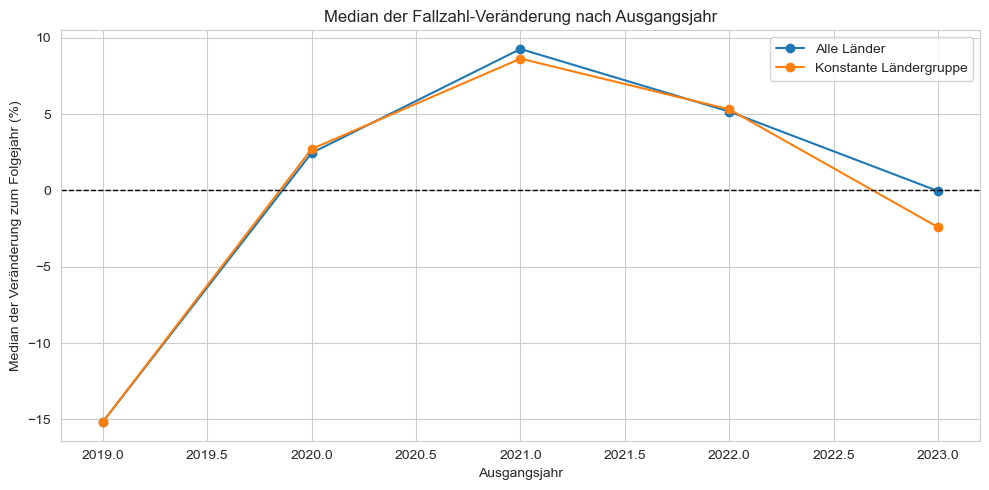

In [293]:
median_change_all = tb_cases_time.groupby("year")[target].median()
median_change_balanced = tb_cases_balanced.groupby("year")[target].median()

plt.figure(figsize=(10, 5))
plt.plot(median_change_all.index, median_change_all, marker="o", label="Alle Länder")
plt.plot(
    median_change_balanced.index,
    median_change_balanced,
    marker="o",
    label="Konstante Ländergruppe",
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Median der Fallzahl-Veränderung nach Ausgangsjahr")
plt.xlabel("Ausgangsjahr")
plt.ylabel("Median der Veränderung zum Folgejahr (%)")
plt.legend()
plt.tight_layout()

pd.DataFrame({
    "Alle Länder": median_change_all,
    "Konstante Ländergruppe": median_change_balanced,
}).round(2)

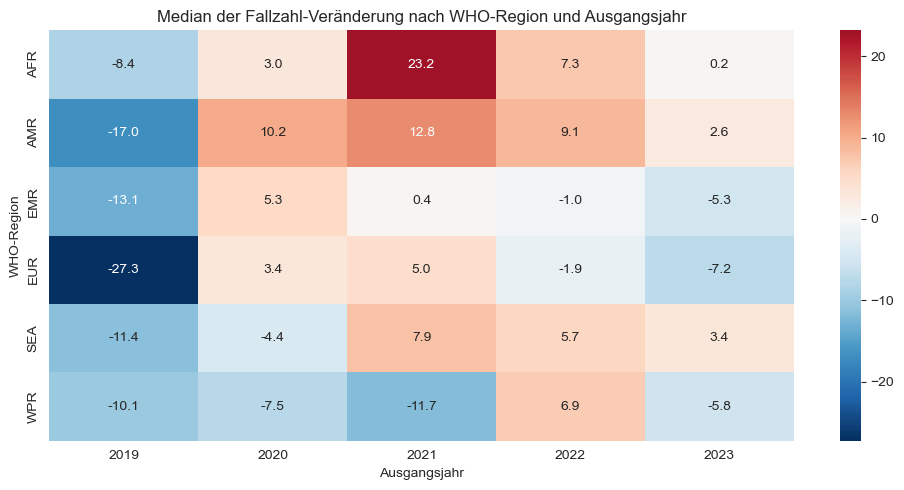

In [294]:
region_year_medians = tb_cases_balanced.pivot_table(
    index="g_whoregion",
    columns="year",
    values=target,
    aggfunc="median",
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    region_year_medians,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0,
)
plt.title("Median der Fallzahl-Veränderung nach WHO-Region und Ausgangsjahr")
plt.xlabel("Ausgangsjahr")
plt.ylabel("WHO-Region")
plt.tight_layout()

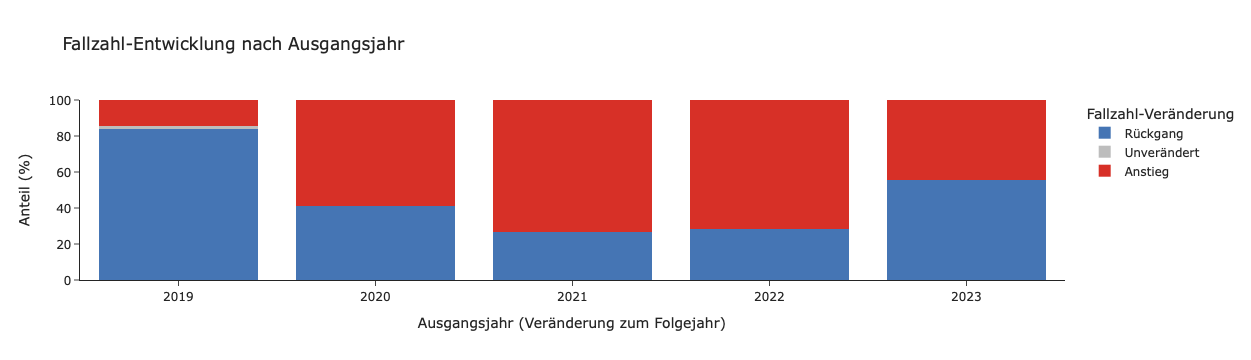

In [295]:
category_order = [
    "Rückgang",
    "Unverändert",
    "Anstieg",
]
change_counts = pd.crosstab(
    tb_cases_balanced["year"],
    tb_cases_balanced["case_change_direction"],
).reindex(columns=category_order, fill_value=0)
change_by_year = change_counts.div(
    change_counts.sum(axis=1), axis=0
).mul(100)

change_plot = change_by_year.reset_index().melt(
    id_vars="year",
    var_name="Fallzahl-Veränderung",
    value_name="Anteil (%)",
)
count_plot = change_counts.reset_index().melt(
    id_vars="year",
    var_name="Fallzahl-Veränderung",
    value_name="Länder",
)
change_plot["Länder"] = count_plot["Länder"]
change_plot["Ausgangsjahr"] = change_plot["year"].astype(str)
fig = px.bar(
    change_plot,
    x="Ausgangsjahr",
    y="Anteil (%)",
    color="Fallzahl-Veränderung",
    hover_data={"Länder": True, "year": False},
    category_orders={"Fallzahl-Veränderung": category_order},
    color_discrete_map={
        "Rückgang": "#4575b4",
        "Unverändert": "#bdbdbd",
        "Anstieg": "#d73027",
    },
    title="Fallzahl-Entwicklung nach Ausgangsjahr",
    template="simple_white",
)
fig.update_traces(marker_line_width=0)
fig.update_layout(
    barmode="stack",
    yaxis_range=[0, 100],
    xaxis_title="Ausgangsjahr (Veränderung zum Folgejahr)",
)
fig.show()

***Bewertung:*** Der deutlichste zeitliche Befund ist der Rückgang der gemeldeten Fälle von 2019 auf 2020 mit einem anschließenden Wiederanstieg. Der ähnliche Verlauf bei allen verfügbaren Ländern und in der konstanten Ländergruppe spricht dafür, dass dieses Muster nicht allein durch die wechselnde Länderabdeckung entsteht.

## Zusammenfassung: 
In den vorliegenden WHO-Daten zeigt sich für den untersuchten Zeitraum kein klarer Zusammenhang zwischen umfangreicherem Screening und einer geringeren Veränderung gemeldeter TB-Fälle im Folgejahr. Auch für Resistenzraten und Therapieergebnisse ergibt sich kein über alle untersuchten Indikatoren hinweg einheitliches Muster. Auch die Durchführung der Analysen ohne markierte Randwerte fördert keine Zusammenhänge zu Tage. Die Untersuchung nach Regionen ergab ebenfalls kein regionsspezifisches Muster. Die ungleiche und teilweise geringe Zahl vertretener Länder begrenzt die Aussagekraft.

Die zeitliche Analyse zeigt jedoch einen deutlicheren Effekt: Die Analyse umfasst die Ausgangsjahre 2019 bis 2023 und Zielwerte im jeweiligen Folgejahr bis 2024 und umschließt damit vollständig die COVID-19-Pandemie. Die dadurch bedingten Belastungen des Gesundheitssystems und die äußerst komplexen Zusammenhänge begründen eine Abnahme der Fallzahlen im Jahr 2020 (exemplarisch z. B. durch die Überlastung der Gesundheitssysteme mit COVID-Patient:innen, aber auch durch Ausgangsbeschränkungen mit resultierend eingeschränkter Diagnostik) und einen "Aufholeffekt" in den Folgejahren. Eine Limitation dieser zeitlichen Analyse ist die nur partielle Abdeckung einiger WHO-Regionen und Länder. Obwohl dies die globale Aussagekraft reduziert, ist das Ergebnis dennoch als vielversprechender und deutlicher Trend zu werten. 

Insgesamt ergeben die Daten damit keinen einheitlichen Beleg für die Ausgangshypothesen, zeigen aber einen deutlichen zeitlichen Trend im Umfeld der COVID-19-Pandemie.